### Libraries

In [1]:
from anndata import AnnData
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scanpy as sc
from sklearn.preprocessing import OneHotEncoder
import torch
from tqdm import tqdm

from sc_exp_design.config import NeuralVelocityFieldConfig
from sc_exp_design.models import FlowMatching

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


### Reading data

In [2]:
PATH = "../../theis/HID01_fcs_concatenated.h5ad"
adata = sc.read_h5ad(PATH)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Subsampling

In [3]:
# optionally subsample the data
KEEP_COPY = True
SUBSAMPLE = True
SUBSAMPLING_DONE = False
SUBSAMPLE_SIZE = 1e-2

if SUBSAMPLE and not SUBSAMPLING_DONE:
    if KEEP_COPY:
        adata_original = adata.copy()
        sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    SUBSAMPLING_DONE = True
adata


AnnData object with n_obs × n_vars = 932786 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Applying transformation

In [4]:
cofactor = 100
key_arcsin = f"X_arcsinh_cof{cofactor}" 
adata.obsm[key_arcsin] = np.arcsinh(adata.X/cofactor)
adata


AnnData object with n_obs × n_vars = 932786 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'
    obsm: 'X_arcsinh_cof100'

### One hot encode conditions.

In [5]:
EXPERIMENTAL_COLUMNS = [
    'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]',
    'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]',
    'ldl_[ng/ml]', 'il3_[ng/ml]', 'o2_[%]',
]
unique_conds = list(adata_original.obs.groupby(by=EXPERIMENTAL_COLUMNS).groups.keys())

unique_conds_str = ["_".join([str(c) for c in cond]) for cond in unique_conds]
adata.obs["protocol"] = adata.obs[EXPERIMENTAL_COLUMNS].astype(str).apply(lambda x: '-'.join(x), axis=1)

ohe = OneHotEncoder()
ohe.fit(adata.obs["protocol"].values.reshape(-1, 1))

one_hot_dict = {}
for cat in adata.obs["protocol"].unique():
    dataset_onehot = (
        ohe.transform(np.array([cat]).reshape(-1, 1)).toarray().flatten()
    )
    one_hot_dict[cat] = dataset_onehot
adata.uns["protocol_one_hot"] = one_hot_dict
adata


/tmp/ipykernel_2863913/4105166555.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unique_conds = list(adata_original.obs.groupby(by=EXPERIMENTAL_COLUMNS).groups.keys())


AnnData object with n_obs × n_vars = 932786 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta', 'protocol_one_hot'
    obsm: 'X_arcsinh_cof100'

### Initializing flow model.

In [6]:
flow_matching = FlowMatching(
    coupling_type="independent",
    generate_from_noise=True,
)


### Preparing data.

In [7]:
flow_matching.prepare_train_data(
    adata,
    sample_rep=key_arcsin,
    perturbations=("protocol", ),
    perturbation_reps={
        "protocol": ("protocol_one_hot",),
    },
)


### Initialize velocity field.

In [8]:
cvf_config = NeuralVelocityFieldConfig(
    flow_dim=adata.obsm[key_arcsin].shape[1],
    encode_state=True,
    state_encoder_output_dim=64,
    state_encoder_mlp_kwargs={
        "hidden_dims": (64, 64),
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_rate": 0.0,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    use_guidance=True,
    encode_conditions=True,
    perturbation_layers_before_pooling={
        "repr_protocol_protocol_one_hot":{
            "input_dim": list(one_hot_dict.values())[0].shape[0],
            "output_dim": 16,
            "hidden_dims": (64, ),
            "use_batchnorm": False,
            "use_dropout": False,
            "dropout_rate": 0.0,
            "activation_class": torch.nn.SELU,
            "final_activation_class": torch.nn.Identity,
        }
    },
    perturbation_layers_after_pooling={
        "hidden_dims": (64, ),
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_rate": 0.0,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    decoder_mlp_kwargs={
        "hidden_dims": (64, 64),
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_rate": 0.0,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
)
flow_matching.prepare_model(
    cvf_config,
    num_time_steps=100,
)


/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/torch/_compile.py:32: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


### Training the model.

Loss: 3.9583: 100%|██████████| 20000/20000 [29:37<00:00, 11.25it/s]  


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

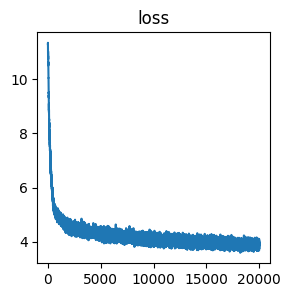

In [9]:
flow_matching.train(
    num_training_steps=20_000,
)
flow_matching.trainer.plot_training_logs()


### Sampling some events for each protocol condition.

In [10]:
out_dict = {}
n_samples_per_protocol = 10_000

for protocol_id, protocol_one_hot in tqdm(adata.uns["protocol_one_hot"].items()):
    cond = torch.from_numpy(protocol_one_hot).repeat(n_samples_per_protocol, 1).float().to(flow_matching.device)
    samples = flow_matching.predict(
        batch={
            "condition": {
                "repr_protocol_protocol_one_hot": cond
            }
        },
    )
    out_dict[protocol_id] = samples.detach().cpu().numpy()


100%|██████████| 72/72 [00:09<00:00,  7.68it/s]


### Defining function to visualize generated samples.

In [23]:
def concatenate_adata_and_plot(
    adata, samples, plot_pcs=True, plot_umap=True, subsample_size=0.1, coloring=["dataset_type"], key="X_pca", **kwargs
):
    obs = {"dataset_type": ["Real" for _ in range(adata.shape[0])] + ["Generated" for _ in range(samples.shape[0])], **kwargs}
    adata_generated = AnnData(X=np.concatenate([adata.obsm[key], samples], axis=0), obs=obs)
    adata_generated.obsm[key] = adata_generated.X.copy()

    if plot_umap:
        sc.pp.subsample(adata_generated, subsample_size)
        sc.pp.neighbors(adata_generated)
        sc.tl.umap(adata_generated)
        
    if plot_pcs:
        sc.pl.embedding(adata_generated, basis=key, color=coloring)
    if plot_umap:
        sc.pl.umap(adata_generated, color=coloring)
    return adata_generated


### Visualizing the generated samples.


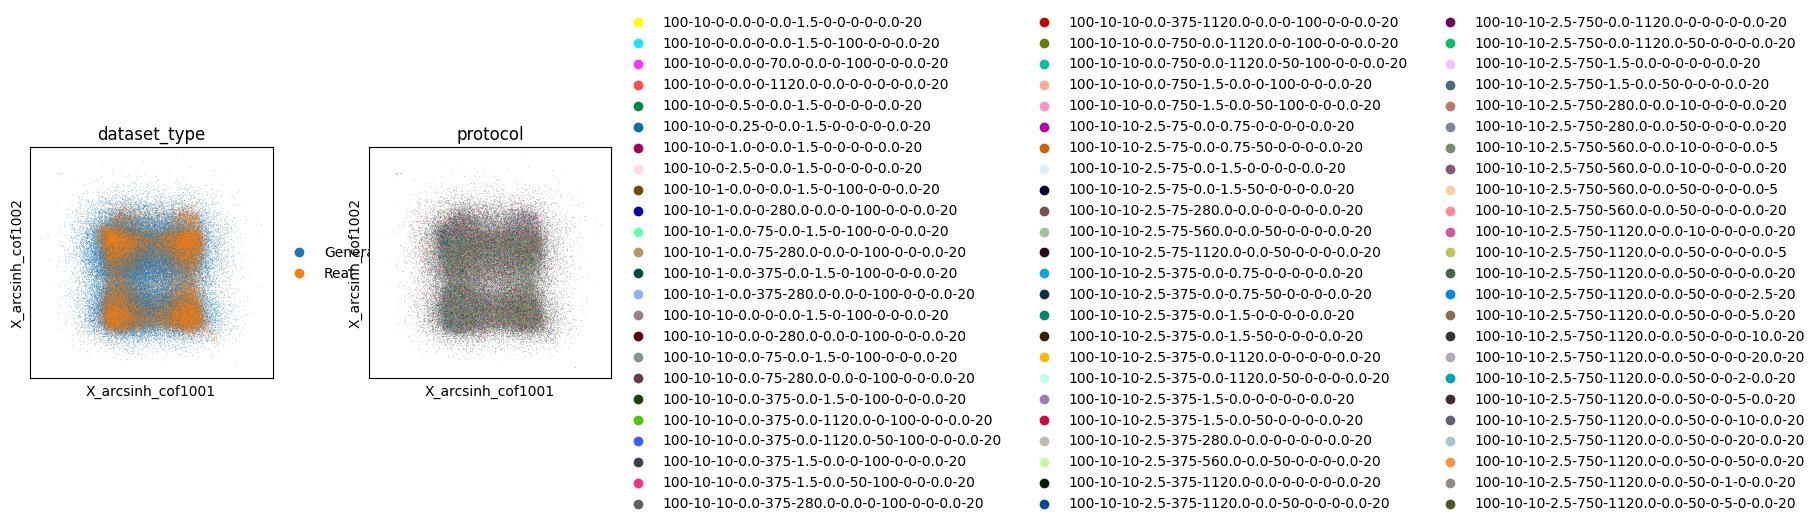

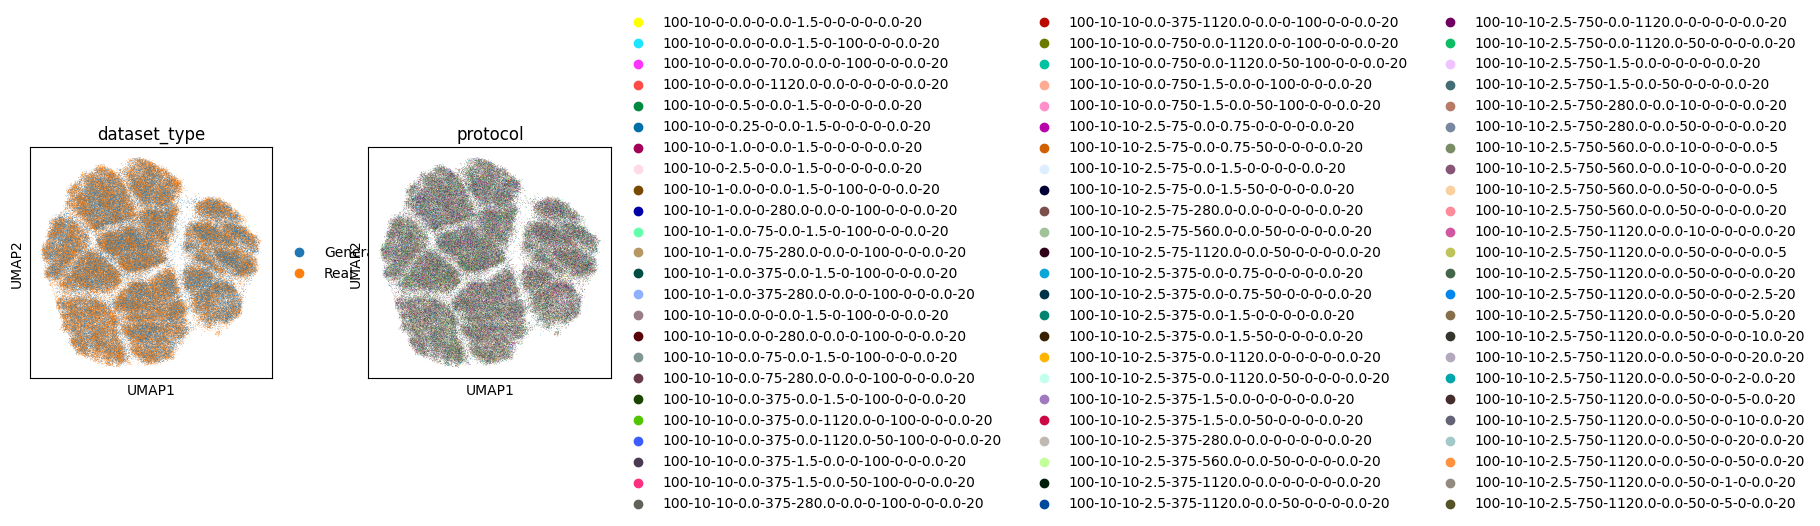

AnnData object with n_obs × n_vars = 165278 × 21
    obs: 'dataset_type', 'protocol'
    uns: 'neighbors', 'umap', 'dataset_type_colors', 'protocol_colors'
    obsm: 'X_arcsinh_cof100', 'X_umap'
    obsp: 'distances', 'connectivities'

In [24]:
samples = np.concatenate(list(out_dict.values()), axis=0)
conds = [
    key for _ in range(n_samples_per_protocol) for key in list(out_dict.keys())
]
concatenate_adata_and_plot(
    adata,
    samples,
    key=key_arcsin,
    coloring=["dataset_type", "protocol"],
    protocol=adata.obs["protocol"].tolist()+conds,
)
